In [1]:
import pandas as pd

df = pd.read_csv("C:\\Users\\Admin\\OneDrive\\Desktop\\MachineLearning\\RANDOM_FOREST_ALGORITHM\\insurance_random_forest_regression\\insurance.csv")
# df["smoker"] = df["smoker"].replace({
#     "no": 0,
#     "yes": 1
# }).astype(int)
df = pd.get_dummies(df,columns=["region","sex","smoker"])

print(df)

      age     bmi  children      charges  region_northeast  region_northwest  \
0      19  27.900         0  16884.92400             False             False   
1      18  33.770         1   1725.55230             False             False   
2      28  33.000         3   4449.46200             False             False   
3      33  22.705         0  21984.47061             False              True   
4      32  28.880         0   3866.85520             False              True   
...   ...     ...       ...          ...               ...               ...   
1333   50  30.970         3  10600.54830             False              True   
1334   18  31.920         0   2205.98080              True             False   
1335   18  36.850         0   1629.83350             False             False   
1336   21  25.800         0   2007.94500             False             False   
1337   61  29.070         0  29141.36030             False              True   

      region_southeast  region_southwes

In [2]:
print(df.dtypes)
X =df.drop(columns=["charges"])
y = df["charges"]

age                   int64
bmi                 float64
children              int64
charges             float64
region_northeast       bool
region_northwest       bool
region_southeast       bool
region_southwest       bool
sex_female             bool
sex_male               bool
smoker_no              bool
smoker_yes             bool
dtype: object


In [3]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)




In [4]:
from xgboost import XGBRegressor
model= XGBRegressor(
        n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [5]:
model.fit(X_train,y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [6]:
prediction = model.predict(X_test)
print(y_test)
print(prediction)

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64
[11012.755   5790.0415 27746.53    9440.946  34210.543   5983.034
  2684.2046 16358.599   5155.7515 10858.234  17932.258   7846.3984
  5421.7905 45358.77   47253.316  44886.29   10713.327  44441.184
  9351.402  24007.727   5854.7227  8998.785   1954.7026  4779.292
 11370.118  12802.488  14416.36    6827.7207 11703.689   4075.3164
  7672.9614 12166.973   3162.1055  5986.3965  4413.959  10719.234
  3723.472   8886.376  24633.695  40541.203   4486.259   4131.2783
 13386.953  14680.963   8322.2295 15345.04    6391.571   6850.608
 42523.08    7220.2773 15154.923   3139.147   6509.575   2184.032
 13757.307  11678.629   4930.6113 40513.273  12241.364  12802.488
 14419.107   5728.205  16578.21    8231.722  12145.37    5670.854
 18452.8

In [7]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test,prediction)

print(mae)

r2 = r2_score(y_test,prediction)

print(r2)

2405.0586404172113
0.8835411990531644


In [8]:
important  = pd.Series(model.feature_importances_,index=X.columns)

print(important.sort_values(ascending=False))

smoker_no           0.883506
bmi                 0.048556
age                 0.038538
region_southwest    0.007515
children            0.006677
region_northwest    0.004994
region_northeast    0.004100
region_southeast    0.003369
sex_female          0.002745
sex_male            0.000000
smoker_yes          0.000000
dtype: float32


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

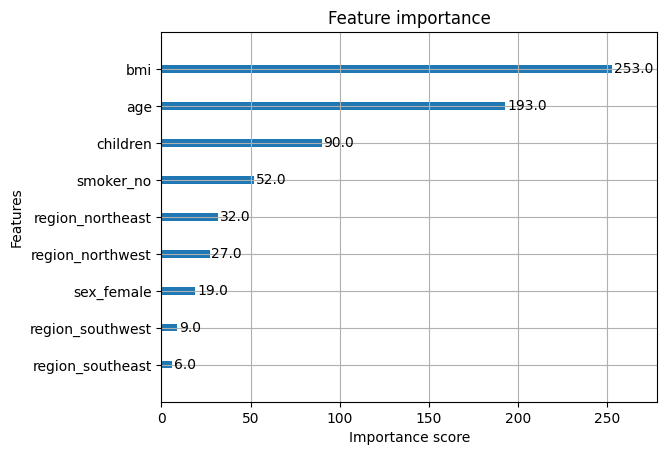

In [9]:
from xgboost import plot_importance
plot_importance(model)

In [10]:
n = int(input("ENTER HOW MANY PERSON'S INSURANCE YOU WANT TO CHECK: "))

for i in range(n):

    print(f"\n------ PERSON {i+1} ------")

    age = int(input("ENTER AGE: "))
    sex = input("ENTER GENDER (male/female): ").lower()
    bmi = float(input("ENTER BMI: "))
    children = int(input("ENTER NUMBER OF CHILDREN: "))

    smoker = input("SMOKER (yes/no): ")
    region = input("ENTER REGION (northeast/northwest/southeast/southwest): ").lower()

    new_person = pd.DataFrame({
        "age": [age],
        "sex": [sex],
        "bmi": [bmi],
        "children": [children],

        "smoker": [smoker],

        "region": [region]
    })

    new_person = pd.get_dummies(new_person)
    new_person = new_person.reindex(columns=X.columns)
    # 60,female,25.84,0,no,northwest,28923.13692   15080
    # 37,male,28.025,2,no,northwest,6203.90175    6746
    # 44,male,31.35,1,yes,northeast,39556.4945    40380
    # 55,female,29.7,2,no,southwest,11881.358     12490

prediction_of_charges = model.predict(new_person)
print("for the following detail ")
print("Insurance Charges of Person {i+1}: ₹",prediction_of_charges[0])


------ PERSON 1 ------
for the following detail 
Insurance Charges of Person {i+1}: ₹ 8189.4497
